<a href="https://colab.research.google.com/github/mmm10138/Machine-Learning/blob/main/HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scientific Machine Learning - Fall 2025 - Homework 1**

# Part 1

## Q1
Using numpy but without using any ML library, implement a feedforward, fully connected neural network function with:
- one hidden layer consisting of 3 neurons, with activation function sigmoid (logistic function)
- one output layer consisting of 1 neuron, with no activation function (or: the activation function is the identity function)

In [2]:
import numpy as np

def neural_network(x, theta):
    """
    Neural network with 1 hidden layer.

    Parameters:
    - x: Input vector of shape (d0,).
    - theta: Parameters of the network, containing:
        * w1: Weights for the first layer of shape (d1, d0) (d1 neurons, d0 inputs).
        * b1: Bias for the first layer of shape (d1,).
        * w2: Weights for the second layer of shape (d2, d1) (d2 neurons, d1 inputs).
        * b2: Bias for the second layer of shape (d2,).

    Returns:
    - Output of the neural network of shape (d2,).
    """

    # Extract parameters
    w1, b1, w2, b2 = theta

    # First layer (hidden layer) with sigmoid activation
    z1 = w1@x+b1 #z1=w1x+b
    a1 = 1/(1+np.exp(-z1)) #a1=sigmoid(z1)

    # Second layer (output layer) with identity activation
    z2 = w2@a1+b2 #z2=w2x+b2
    output = z2  # Identity activation

    return output

## Q2
Test your neural network on the following input
$$
x = \begin{bmatrix} 0.5 \\ -0.2 \end{bmatrix}
$$
with the following parameters:
$$
w_1 = \begin{bmatrix} 1.0 & 0.0 \\ 0.5 & 0.5 \\ 0.0 & 1.0 \end{bmatrix}, \qquad
b_1 = \begin{bmatrix} 1.0 \\ 0.1 \\ -0.3 \end{bmatrix}
$$
$$
w_2 = \begin{bmatrix} -2.0 & 10.0 & 1.0 \end{bmatrix}, \qquad
b_2 = \begin{bmatrix} 0.2 \end{bmatrix}
$$
Hint: The value should be roughly 4.564.


In [3]:
# Example
x = np.array([0.5, -0.2])  # Input vector
# Weights for the first layer
w1 = np.array([[1.0,0.0],
              [0.5,0.5],
              [0.0,1.0]])
b1 = np.array([1.0,0.1,-0.3]) # Bias for the first layer
w2 = np.array([-2.0,10.0,1.0]) # Weights for the second layer
b2 = np.array([0.2]) # Bias for the second layer

theta = (w1, b1, w2, b2)

output = neural_network(x, theta)
output

array([4.56415673])

## Q3
Use the following function to produce a 3D plot of the function, with the same parameter $\theta=(w_1,b_1,w_2,b_2)$, on the square $[-10,10] \times [-10,10]$.

In [4]:
# Define the function for 3D plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_neural_network_3d(theta):
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.zeros(X.shape)

    # Compute the network output for each (x, y) pair
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            z_val = neural_network(np.array([X[i, j], Y[i, j]]), theta)
            Z[i, j] = z_val.item()

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    ax.set_title("Neural Network Output (2D)")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Network Output")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()


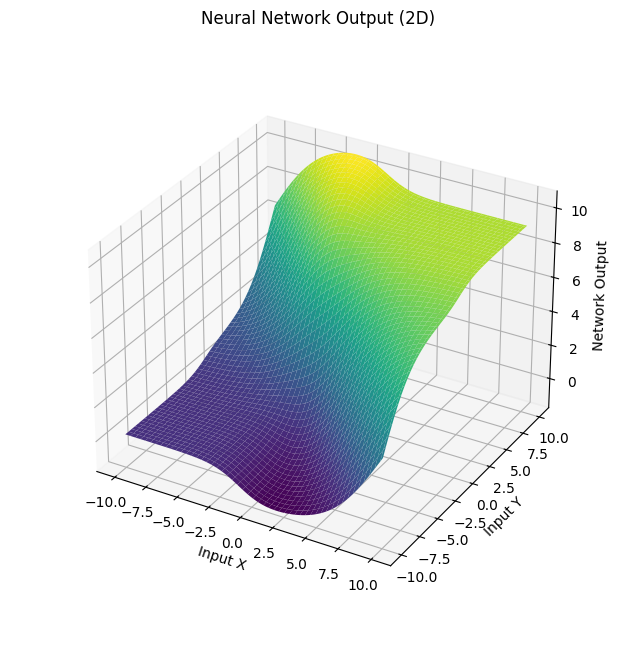

In [5]:
# Plot the neural network in 3D
# Use for instance:
plot_neural_network_3d(theta)

## Q4

Consider the following target function $x \mapsto \cos(\pi x_1/10)\cos(\pi x_2/10)$ plotted below:

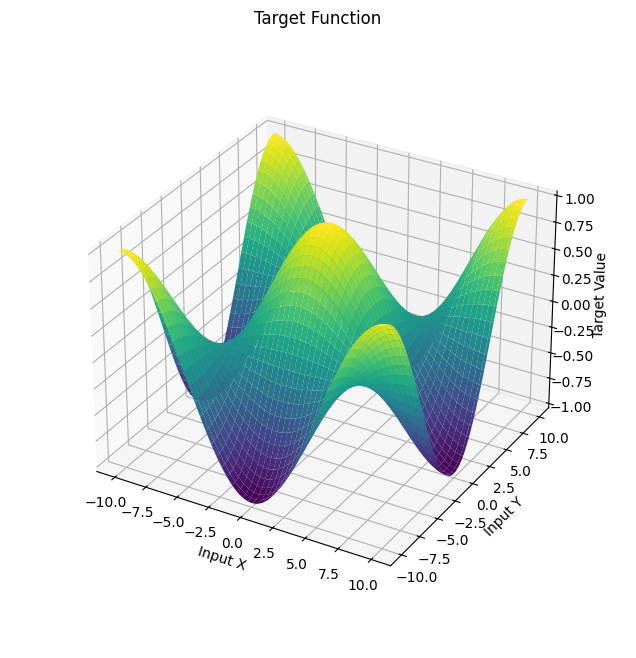

In [6]:
def target_func(x):
  return np.cos(np.pi*x[0]/10)*np.cos(np.pi*x[1]/10)

def plot_func_3d():
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.zeros(X.shape)

    # Compute the function value for each (x, y) pair
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            z_val = target_func([X[i, j], Y[i, j]])
            Z[i, j] = z_val

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    ax.set_title("Target Function")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Target Value")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()

# Plot the target function in 3D
plot_func_3d()

Explain in words how you could tune the parameter $\theta$ so that the neural network function would be close to this target function.

The parameter θ could be tuned by the taking points and copmuting the target value at each. Then, measuring how far the network's output is from the target at those points by using the averaged squared error. This has to start with random values for θ and moving in the direction that lowers this error. By the Universal Approximation Theorem, using more hidden neurons would let the network to get as close to the target as we want.

# Part 2

## Q1

Implement the same neural network as before, but now using the PyTorch library.

In [7]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNN(nn.Module):
    def __init__(self):
        super(FeedforwardNN, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2,3)  # 2 inputs, 3 neurons in hidden layer
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(3,1)  # 3 inputs, 1 output neuron

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out


## Q2

Evaluate the neural network using the same parameters as in the previous part, and on the same input $x$.
Hint: The value should still be roughly 4.564.

In [8]:
# Initialize the network
model = FeedforwardNN()

# Manually set weights and biases to match the example
with torch.no_grad():
    model.fc1.weight = torch.nn.Parameter(torch.tensor([[1.0, 0.0], [0.5, 0.5], [0.0, 1.0]]))
    model.fc1.bias = torch.nn.Parameter(torch.tensor([1.0,0.1,-0.3]))
    model.fc2.weight = torch.nn.Parameter(torch.tensor([[-2.0,10.0,1.0]]))
    model.fc2.bias = torch.nn.Parameter(torch.tensor([0.2]))

# Define the input
x = torch.tensor([0.5, -0.2])

# Forward pass: calculate the output
output = model(x)

print("Network output:", output.item())

Network output: 4.564156532287598


## Q3

Use the following code to plot your function:

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_neural_network_pytorch_3d(model):
    # Generate a meshgrid over the input space [-10, 10] x [-10, 10]
    x_vals = np.linspace(-10, 10, 100)
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros(X.shape)

    # Evaluate the neural network over the grid
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            # Prepare the input in the form [x, y]
            input_tensor = torch.FloatTensor([X[i, j], Y[i, j]])
            Z[i, j] = model(input_tensor).item()  # Get the network output

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')

    # Add plot labels
    ax.set_title("Neural Network Output over Input Space [-10, 10] x [-10, 10]")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Input Y")
    ax.set_zlabel("Network Output")
    #ax.dist = 13
    ax.set_box_aspect(None, zoom=0.85)

    plt.show()

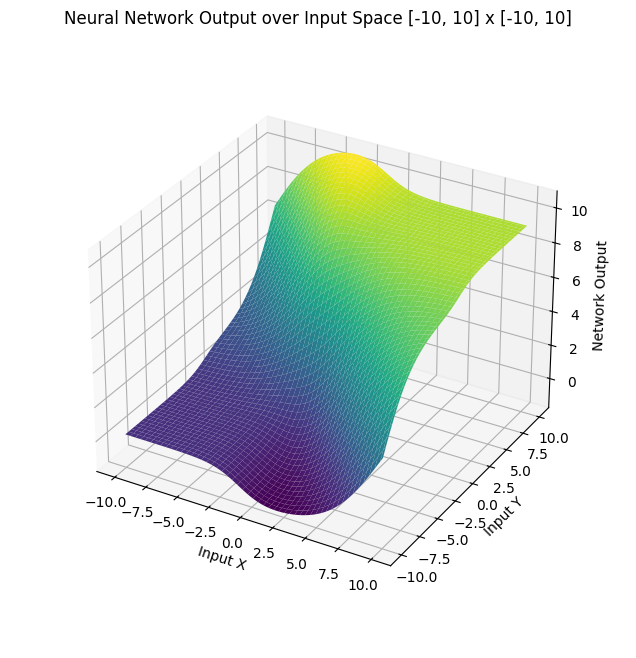

In [10]:
# Call the above function to plot your neural network, for isntance:
plot_neural_network_pytorch_3d(model)

## Q4
Using SGD, train the neural network to be close to the target function defined above. To this end, use the loss function defined as the mean-squared distance between the neural network function and the target function, when the input is sampled uniformly at random on $[-10,10] \times [-10,10]$.

Set the learning rate to 0.01. Train for $200$ epochs, using $10$ mini-batches of size $8$ in each epoch. Print the loss at each epoch.

At the end of training, plot your neural network function in 3D.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Define the target function (in PyTorch)
def target_function(x):
    return torch.cos(np.pi * x[:, 0] / 10) * torch.cos(np.pi * x[:, 1] / 10)

# Initialize the network, loss function, and optimizer
model = FeedforwardNN()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 8  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred,y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')


Epoch [1/200], Loss: 0.366643
Epoch [2/200], Loss: 0.428855
Epoch [3/200], Loss: 0.313542
Epoch [4/200], Loss: 0.317302
Epoch [5/200], Loss: 0.308899
Epoch [6/200], Loss: 0.252314
Epoch [7/200], Loss: 0.276704
Epoch [8/200], Loss: 0.221344
Epoch [9/200], Loss: 0.342356
Epoch [10/200], Loss: 0.230274
Epoch [11/200], Loss: 0.247514
Epoch [12/200], Loss: 0.262205
Epoch [13/200], Loss: 0.211751
Epoch [14/200], Loss: 0.335495
Epoch [15/200], Loss: 0.252828
Epoch [16/200], Loss: 0.309937
Epoch [17/200], Loss: 0.230885
Epoch [18/200], Loss: 0.241265
Epoch [19/200], Loss: 0.304393
Epoch [20/200], Loss: 0.276825
Epoch [21/200], Loss: 0.217548
Epoch [22/200], Loss: 0.258386
Epoch [23/200], Loss: 0.264748
Epoch [24/200], Loss: 0.285095
Epoch [25/200], Loss: 0.276056
Epoch [26/200], Loss: 0.284480
Epoch [27/200], Loss: 0.225530
Epoch [28/200], Loss: 0.263135
Epoch [29/200], Loss: 0.246123
Epoch [30/200], Loss: 0.290036
Epoch [31/200], Loss: 0.261973
Epoch [32/200], Loss: 0.273450
Epoch [33/200], L

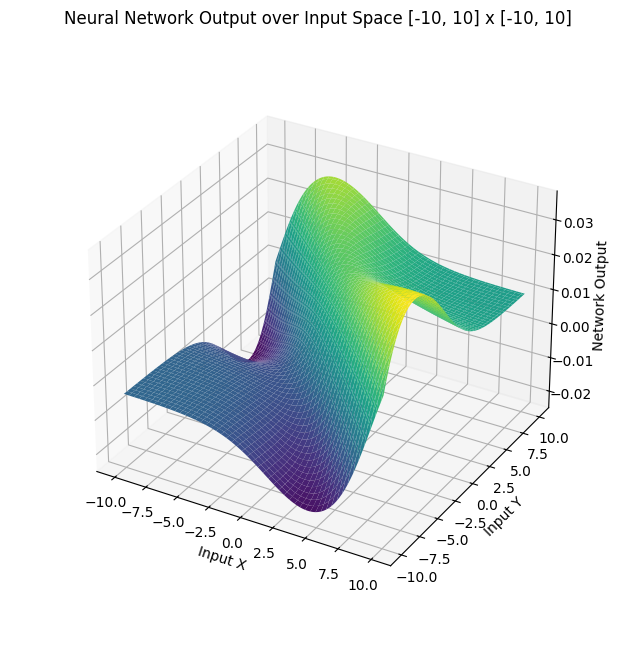

In [12]:
plot_neural_network_pytorch_3d(model)

## Q5
Although neural networks with a single hidden layer satisfy a universal approximation theorem, they may require more than $3$ neurons in order to approximate well the target function. Let us try with more neurons.

Define a new neural network with the same architecture except for the fact that it has $200$ neurons (instead of $3$) in the hidden layer. Repeat the training and plot your result.

Epoch [1/200], Loss: 0.244084
Epoch [2/200], Loss: 0.271914
Epoch [3/200], Loss: 0.327934
Epoch [4/200], Loss: 0.278872
Epoch [5/200], Loss: 0.224092
Epoch [6/200], Loss: 0.274301
Epoch [7/200], Loss: 0.287849
Epoch [8/200], Loss: 0.253158
Epoch [9/200], Loss: 0.226317
Epoch [10/200], Loss: 0.265841
Epoch [11/200], Loss: 0.234107
Epoch [12/200], Loss: 0.232518
Epoch [13/200], Loss: 0.240888
Epoch [14/200], Loss: 0.309541
Epoch [15/200], Loss: 0.252376
Epoch [16/200], Loss: 0.256003
Epoch [17/200], Loss: 0.232941
Epoch [18/200], Loss: 0.291578
Epoch [19/200], Loss: 0.237909
Epoch [20/200], Loss: 0.301153
Epoch [21/200], Loss: 0.216600
Epoch [22/200], Loss: 0.300860
Epoch [23/200], Loss: 0.292279
Epoch [24/200], Loss: 0.267469
Epoch [25/200], Loss: 0.219624
Epoch [26/200], Loss: 0.326307
Epoch [27/200], Loss: 0.230064
Epoch [28/200], Loss: 0.240436
Epoch [29/200], Loss: 0.299231
Epoch [30/200], Loss: 0.265020
Epoch [31/200], Loss: 0.205798
Epoch [32/200], Loss: 0.221519
Epoch [33/200], L

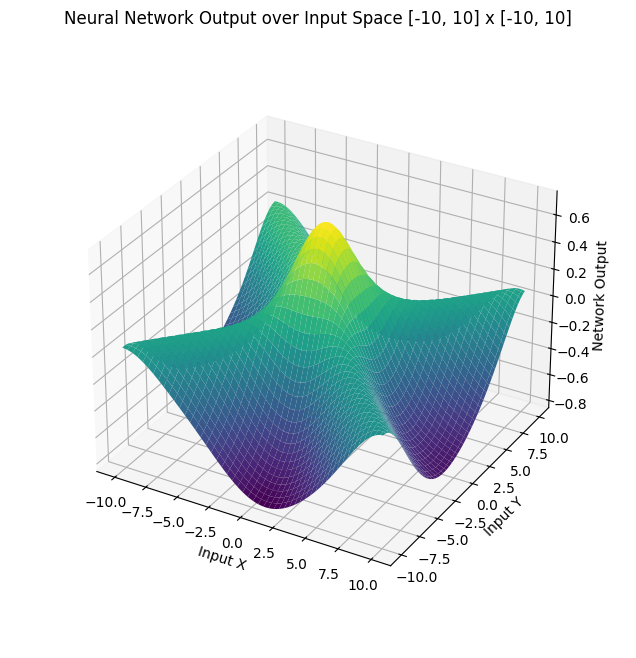

In [13]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2,200)  # 2 inputs, 200 neurons in hidden layer
        self.activation = nn.Sigmoid() # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(200,1)  # 200 inputs, 1 output neuron

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
model_wide = FeedforwardNNWide()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_wide.parameters(), lr=0.01)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 8  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model_wide(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred,y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')

plot_neural_network_pytorch_3d(model_wide)

# Bonus Questions

- At the end of training, plot the loss vs epochs.
- Try to get a better fit of the target function (e.g., with more neurons, more layers, a different learning rate, or a different mini-batch size).

In [ ]:
# TODO: Hint: use larger mini-batch and smaller LR (together)

Epoch [1/200], Loss: 0.303102
Epoch [2/200], Loss: 0.266184
Epoch [3/200], Loss: 0.241024
Epoch [4/200], Loss: 0.243835
Epoch [5/200], Loss: 0.253536
Epoch [6/200], Loss: 0.233905
Epoch [7/200], Loss: 0.241151
Epoch [8/200], Loss: 0.249306
Epoch [9/200], Loss: 0.237672
Epoch [10/200], Loss: 0.241667
Epoch [11/200], Loss: 0.236675
Epoch [12/200], Loss: 0.239014
Epoch [13/200], Loss: 0.234775
Epoch [14/200], Loss: 0.244369
Epoch [15/200], Loss: 0.240261
Epoch [16/200], Loss: 0.233471
Epoch [17/200], Loss: 0.249076
Epoch [18/200], Loss: 0.240572
Epoch [19/200], Loss: 0.245200
Epoch [20/200], Loss: 0.236714
Epoch [21/200], Loss: 0.228250
Epoch [22/200], Loss: 0.238210
Epoch [23/200], Loss: 0.232064
Epoch [24/200], Loss: 0.231913
Epoch [25/200], Loss: 0.250976
Epoch [26/200], Loss: 0.241584
Epoch [27/200], Loss: 0.227745
Epoch [28/200], Loss: 0.246203
Epoch [29/200], Loss: 0.222986
Epoch [30/200], Loss: 0.239407
Epoch [31/200], Loss: 0.243046
Epoch [32/200], Loss: 0.225016
Epoch [33/200], L

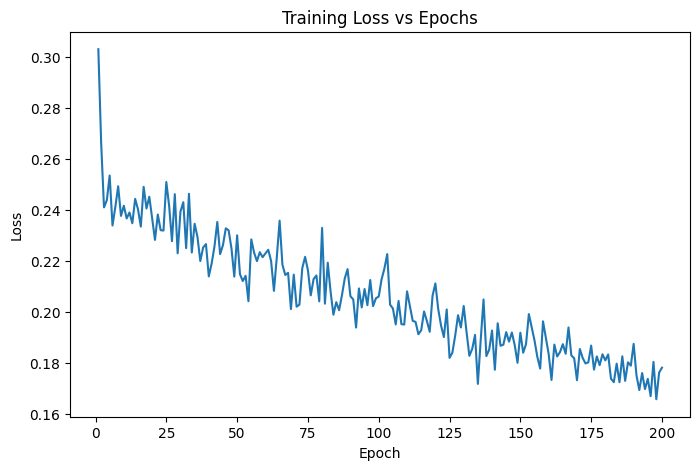

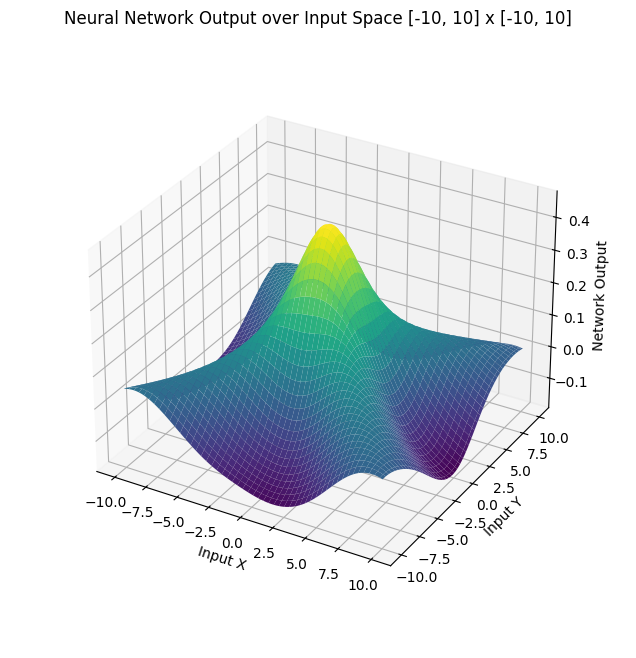

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2, 600)
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(600, 1)

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
model_wide = FeedforwardNNWide()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_wide.parameters(), lr=0.001)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 100  # Batch size

#Store the average loss of each epoch
loss_history=[]

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model_wide(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred, y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()  # Zero out gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters

        epoch_loss += loss.item()

    avg_loss=epoch_loss/num_batches
    loss_history.append(avg_loss)
    if (epoch+1)%1==0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

plt.figure(figsize=(8,5))
plt.plot(range(1,epochs+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()
plot_neural_network_pytorch_3d(model_wide)

With a different learning rate and minibatch size, it explodes. Why?

Epoch [1/200], Loss: 21056.988318
Epoch [2/200], Loss: 288273980640.599976
Epoch [3/200], Loss: 92693918745257568.000000
Epoch [4/200], Loss: 22702256054653788160.000000
Epoch [5/200], Loss: 135265832787792363520000.000000
Epoch [6/200], Loss: 131278233998774070832908992512.000000
Epoch [7/200], Loss: 114148605956896704752365235192463360.000000
Epoch [8/200], Loss: inf
Epoch [9/200], Loss: nan
Epoch [10/200], Loss: nan
Epoch [11/200], Loss: nan
Epoch [12/200], Loss: nan
Epoch [13/200], Loss: nan
Epoch [14/200], Loss: nan
Epoch [15/200], Loss: nan
Epoch [16/200], Loss: nan
Epoch [17/200], Loss: nan
Epoch [18/200], Loss: nan
Epoch [19/200], Loss: nan
Epoch [20/200], Loss: nan
Epoch [21/200], Loss: nan
Epoch [22/200], Loss: nan
Epoch [23/200], Loss: nan
Epoch [24/200], Loss: nan
Epoch [25/200], Loss: nan
Epoch [26/200], Loss: nan
Epoch [27/200], Loss: nan
Epoch [28/200], Loss: nan
Epoch [29/200], Loss: nan
Epoch [30/200], Loss: nan
Epoch [31/200], Loss: nan
Epoch [32/200], Loss: nan
Epoch

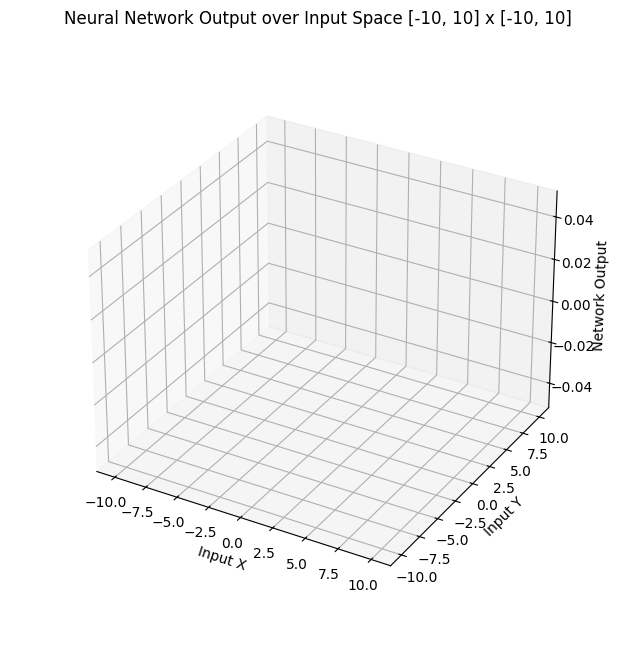

In [14]:
import torch
import torch.nn as nn

# Define the feedforward neural network
class FeedforwardNNWide(nn.Module):
    def __init__(self):
        super(FeedforwardNNWide, self).__init__()
        # Define the first layer (input to hidden layer)
        self.fc1 = nn.Linear(2, 600)
        # torch.nn.init.normal_(self.fc1, mean=0.0, std=0.001)
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.0001)
        self.activation = nn.Sigmoid()  # Sigmoid activation function

        # Define the second layer (hidden to output layer)
        self.fc2 = nn.Linear(600, 1)
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.0001)

    def forward(self, x):
        # Pass through the first layer, then apply the activation
        out = self.activation(self.fc1(x))
        # Pass through the second layer (output layer without activation)
        out = self.fc2(out)
        return out

# Initialize the network, loss function, and optimizer
model_wide = FeedforwardNNWide()

# Initialization of parameters
# torch.nn.init.normal_(model.weight, mean=0.0, std=0.001)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model_wide.parameters(), lr=0.01)

# Training parameters
epochs = 200  # Number of epochs
num_batches = 10  # Number of batches per epoch
batch_size = 8  # Batch size

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(num_batches):
        # Sample random input uniformly from [-10, 10] x [-10, 10]
        x_train = torch.FloatTensor(batch_size, 2).uniform_(-10, 10)
        y_train = target_function(x_train).unsqueeze(1)  # Compute target function values

        # Forward pass
        y_pred = model_wide(x_train)

        # Compute loss (mean squared error)
        loss = loss_fn(y_pred, y_train)

        # Backward pass and optimization step
        optimizer.zero_grad()  # Zero out gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters

        epoch_loss += loss.item()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/num_batches:.6f}')

plot_neural_network_pytorch_3d(model_wide)